<a href="https://colab.research.google.com/github/hannahandkush/Coursework/blob/main/Assignment4_Avcad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

##1. Using an appropriate visualization, explore how Mean Annual Temperature (Temp_ann) may affect the presence of Salmo trutta fario (Brown Trout).

### Conclusion
Probability of sighting Brown Trout decreases with increasing annual temperature above 7 degrees celcius.

Warmer annual temperatures generally lead to a lower probability of sighting Brown Trout in this dataset.

In [37]:
print(df.columns.tolist())

['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name', 'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect', 'Calib_hydrol', 'Calib_morphol', 'Calib_wqual', 'Geomorph1', 'Geomorph2', 'Geomorph3', 'Water_source_type', 'Flow_regime', 'Altitude', 'Geological_typology', 'Actual_river_slope', 'Natural_sediment', 'Elevation_mean_catch', 'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul', 'Barriers_catchment_down', 'Barriers_river_segment_up', 'Barriers_river_segment_down', 'Barriers_number_river_segment_up', 'Barriers_number_river_segment_down', 'Barriers_distance_river_segment_up', 'Barriers_distance_river_segment_down', 'Impoundment', 'Hydropeaking', 'Water_abstraction', 'Hydro_mod', 'Temperature_impact', 'Velocity_increase', 'Reservoir_flushing', 'Sedimentation', 'Channelisation', 'Cross_sec', 'Instream_habitat', 'Riparian_vegetation', 'Embankment', 'Floodprotection', 'Floodplain', 'Toxic_substances', 'Acidification', 'Water_quality_index', 'Eutrophication', 'Organic_p

In [1]:
import requests
import zipfile
import io

zip_url = "https://github.com/isa-ulisboa/greends-avcad-2026/raw/main/examples/EFIplus_medit.zip"

# Download the zip file
response = requests.get(zip_url)
response.raise_for_status()  # Raise an exception for bad status codes

# Unzip the contents to the current directory
with zipfile.ZipFile(io.BytesIO(response.content), 'r') as zip_ref:
    zip_ref.extractall('.')

print("File downloaded and unzipped successfully.")

File downloaded and unzipped successfully.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

# Load the dataset
df = pd.read_csv('EFIplus_medit.csv', delimiter=';')

df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [3]:
if 'temp_ann' in df.columns:
    print("Column 'temp_ann' found in the DataFrame. Here are its descriptive statistics:")
    print(df['temp_ann'].describe())
else:
    print("Column 'temp_ann' not found in the DataFrame.")

Column 'temp_ann' found in the DataFrame. Here are its descriptive statistics:
count    4841.000000
mean       13.261950
std         2.172315
min         3.900000
25%        12.000000
50%        13.400000
75%        14.600000
max        18.300000
Name: temp_ann, dtype: float64


In [4]:
df_selected = df[['Salmo trutta fario', 'temp_ann']]
print(df_selected.head())

   Salmo trutta fario  temp_ann
0                   0      17.6
1                   1       9.3
2                   1      10.1
3                   1      10.1
4                   1      10.3


In [38]:
# Drop rows where 'temp_ann' is NaN to avoid IntCastingNaNError
df_selected_cleaned = df_selected.dropna(subset=['temp_ann']).copy()

df_selected_cleaned['temp_ann_deg'] = df_selected_cleaned['temp_ann'].round().astype(int)

probability_table = df_selected_cleaned.groupby('temp_ann_deg')['Salmo trutta fario'].mean().reset_index()
probability_table.rename(columns={'Salmo trutta fario': 'Probability of Sighting Salmo trutta fario'}, inplace=True)

print(probability_table)

    temp_ann_deg  Probability of Sighting Salmo trutta fario
0              4                                    1.000000
1              5                                    1.000000
2              6                                    1.000000
3              7                                    1.000000
4              8                                    0.985714
5              9                                    0.972727
6             10                                    0.940520
7             11                                    0.851124
8             12                                    0.781058
9             13                                    0.714118
10            14                                    0.658937
11            15                                    0.397727
12            16                                    0.053299
13            17                                    0.012195
14            18                                    0.000000


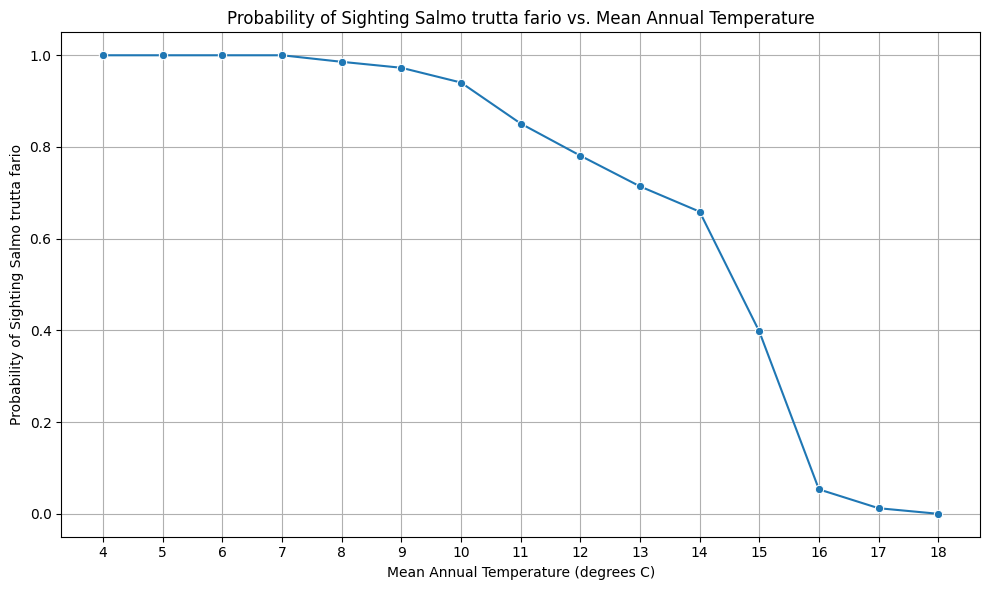

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(x='temp_ann_deg', y='Probability of Sighting Salmo trutta fario', data=probability_table, marker='o')
plt.title('Probability of Sighting Salmo trutta fario vs. Mean Annual Temperature')
plt.xlabel('Mean Annual Temperature (degrees C)')
plt.ylabel('Probability of Sighting Salmo trutta fario')
plt.grid(True)
plt.xticks(probability_table['temp_ann_deg'])
plt.tight_layout()
plt.show()

---
## 2. . Check the same effect but now separately for Minho and Tagus catchments and comparing the “effect sizes”

### Conclusion
Effect sizes vary significantly by region.

*   little to no effect of mean annual temperature on sightings probability of Brown Trout in Minho catchment,
*   large negative effect of increasing temperature on sighting probability of Brown Trout in Tagus catchment

In [11]:
catchments_to_analyze = ['Tejo', 'Minho']

df_filtered = df[df['Catchment_name'].isin(catchments_to_analyze)].copy()

df_filtered_cleaned = df_filtered[['Salmo trutta fario', 'temp_ann', 'Catchment_name']].dropna(subset=['temp_ann'])

df_filtered_cleaned['temp_ann_deg'] = df_filtered_cleaned['temp_ann'].round().astype(int)

probability_by_catchment = df_filtered_cleaned.groupby(['Catchment_name', 'temp_ann_deg'])['Salmo trutta fario'].mean().reset_index()
probability_by_catchment.rename(columns={'Salmo trutta fario': 'Probability of Sighting Salmo trutta fario'}, inplace=True)

print("Probability of Sighting Salmo trutta fario by Catchment and Temperature:")
print(probability_by_catchment)

Probability of Sighting Salmo trutta fario by Catchment and Temperature:
   Catchment_name  temp_ann_deg  Probability of Sighting Salmo trutta fario
0           Minho             7                                    1.000000
1           Minho             8                                    1.000000
2           Minho             9                                    1.000000
3           Minho            10                                    1.000000
4           Minho            11                                    1.000000
5           Minho            12                                    0.980769
6           Minho            13                                    0.969512
7           Minho            14                                    0.980000
8           Minho            15                                    0.976744
9            Tejo             8                                    1.000000
10           Tejo             9                                    0.954545
11           Te

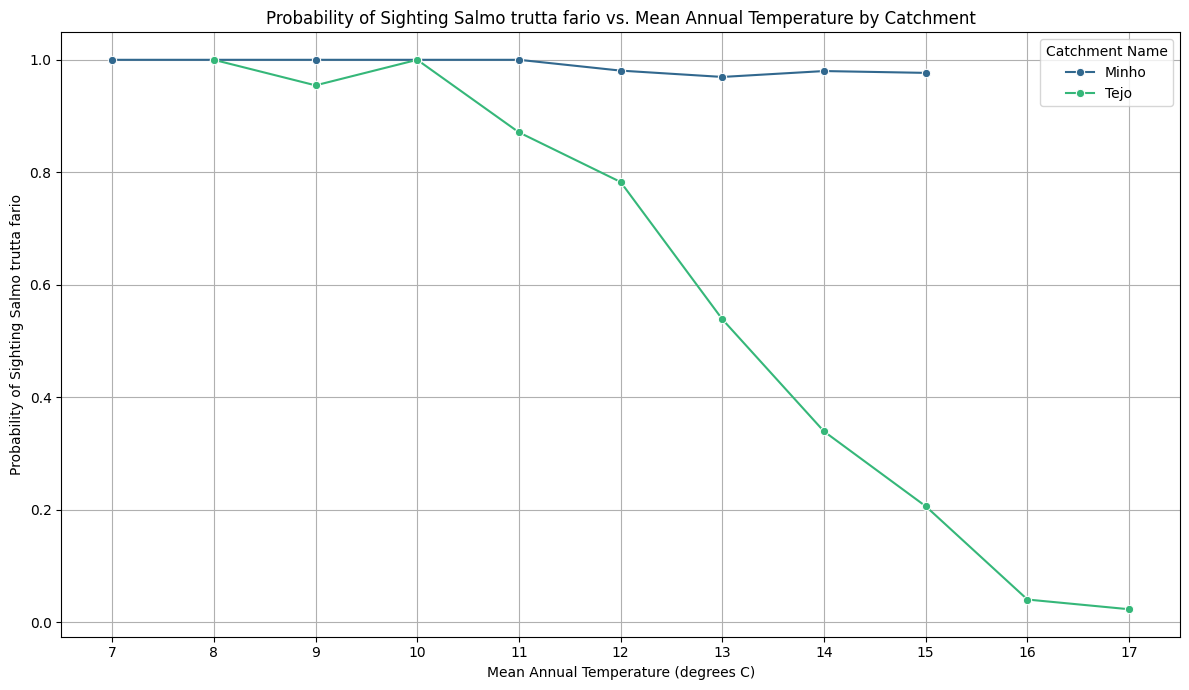

In [12]:
plt.figure(figsize=(12, 7))
sns.lineplot(x='temp_ann_deg', y='Probability of Sighting Salmo trutta fario', hue='Catchment_name', data=probability_by_catchment, marker='o', palette='viridis')
plt.title('Probability of Sighting Salmo trutta fario vs. Mean Annual Temperature by Catchment')
plt.xlabel('Mean Annual Temperature (degrees C)')
plt.ylabel('Probability of Sighting Salmo trutta fario')
plt.grid(True)
plt.xticks(sorted(probability_by_catchment['temp_ann_deg'].unique()))
plt.legend(title='Catchment Name')
plt.tight_layout()
plt.show()

Difference in Probability of Sighting Salmo trutta fario (Tejo - Minho) at each Temperature Degree:
Catchment_name     Minho      Tejo  Difference (Tejo - Minho)
temp_ann_deg                                                 
7               1.000000       NaN                        NaN
8               1.000000  1.000000                   0.000000
9               1.000000  0.954545                  -0.045455
10              1.000000  1.000000                   0.000000
11              1.000000  0.870968                  -0.129032
12              0.980769  0.782609                  -0.198161
13              0.969512  0.538462                  -0.431051
14              0.980000  0.338983                  -0.641017
15              0.976744  0.205882                  -0.770862
16                   NaN  0.040000                        NaN
17                   NaN  0.022727                        NaN


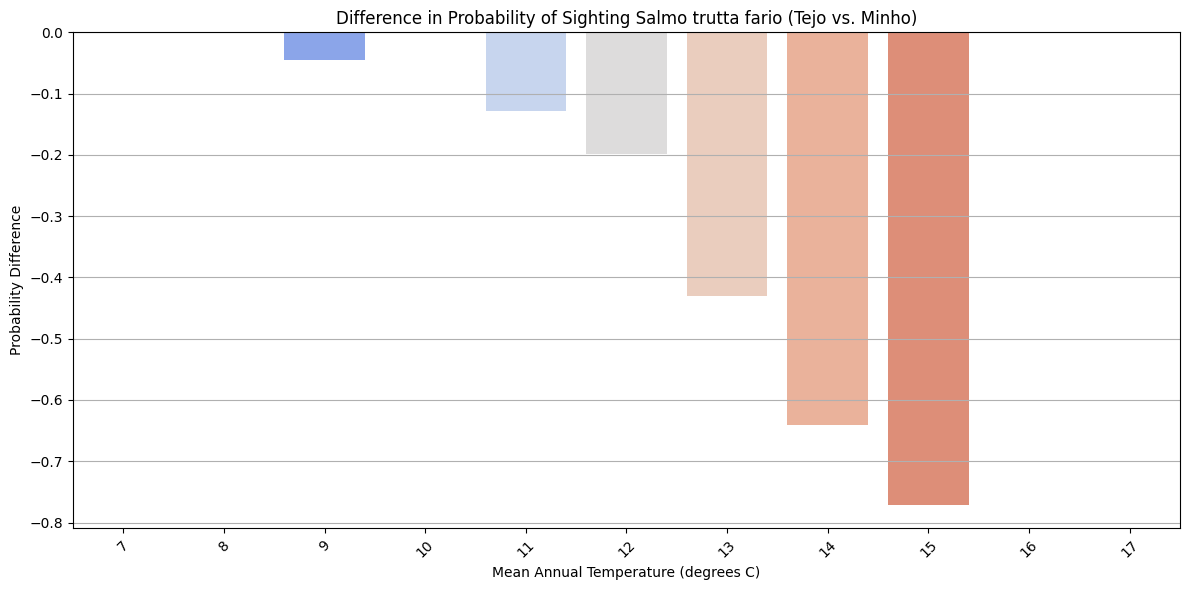

In [14]:
pivot_table = probability_by_catchment.pivot(index='temp_ann_deg', columns='Catchment_name', values='Probability of Sighting Salmo trutta fario')
pivot_table['Difference (Tejo - Minho)'] = pivot_table['Tejo'] - pivot_table['Minho']

print("Difference in Probability of Sighting Salmo trutta fario (Tejo - Minho) at each Temperature Degree:")
print(pivot_table)

plt.figure(figsize=(12, 6))
sns.barplot(x=pivot_table.index, y='Difference (Tejo - Minho)', hue=pivot_table.index, data=pivot_table, palette='coolwarm', legend=False)
plt.title('Difference in Probability of Sighting Salmo trutta fario (Tejo vs. Minho)')
plt.xlabel('Mean Annual Temperature (degrees C)')
plt.ylabel('Probability Difference')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 3. Test, using both visualization and hypothesis testing methods, if the actual_river_slope is drawn from a normal distribution.

###Conclusion
Actual River Slope data is not normally distributed, it is heavily right skewed

In [25]:
print(df.columns.tolist())

['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name', 'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect', 'Calib_hydrol', 'Calib_morphol', 'Calib_wqual', 'Geomorph1', 'Geomorph2', 'Geomorph3', 'Water_source_type', 'Flow_regime', 'Altitude', 'Geological_typology', 'Actual_river_slope', 'Natural_sediment', 'Elevation_mean_catch', 'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul', 'Barriers_catchment_down', 'Barriers_river_segment_up', 'Barriers_river_segment_down', 'Barriers_number_river_segment_up', 'Barriers_number_river_segment_down', 'Barriers_distance_river_segment_up', 'Barriers_distance_river_segment_down', 'Impoundment', 'Hydropeaking', 'Water_abstraction', 'Hydro_mod', 'Temperature_impact', 'Velocity_increase', 'Reservoir_flushing', 'Sedimentation', 'Channelisation', 'Cross_sec', 'Instream_habitat', 'Riparian_vegetation', 'Embankment', 'Floodprotection', 'Floodplain', 'Toxic_substances', 'Acidification', 'Water_quality_index', 'Eutrophication', 'Organic_p

In [30]:
# Perform Shapiro-Wilk Test for normality
# Null Hypothesis (H0): The data is normally distributed.
# Alternative Hypothesis (H1): The data is not normally distributed.

# Drop NaN values as Shapiro-Wilk test does not handle them
river_slope_data = df['Actual_river_slope'].dropna()

if len(river_slope_data) > 3: # Shapiro-Wilk test requires at least 3 data points
    stat, p = stats.shapiro(river_slope_data)
    print('Shapiro-Wilk Test Statistics: %.3f, p=%.3f' % (stat, p))

    alpha = 0.05
    if p > alpha:
        print('Sample looks Gaussian (fail to reject H0)')
    else:
        print('Sample does not look Gaussian (reject H0)')
else:
    print("Not enough data points to perform Shapiro-Wilk test (need at least 3).")

Shapiro-Wilk Test Statistics: 0.516, p=0.000
Sample does not look Gaussian (reject H0)


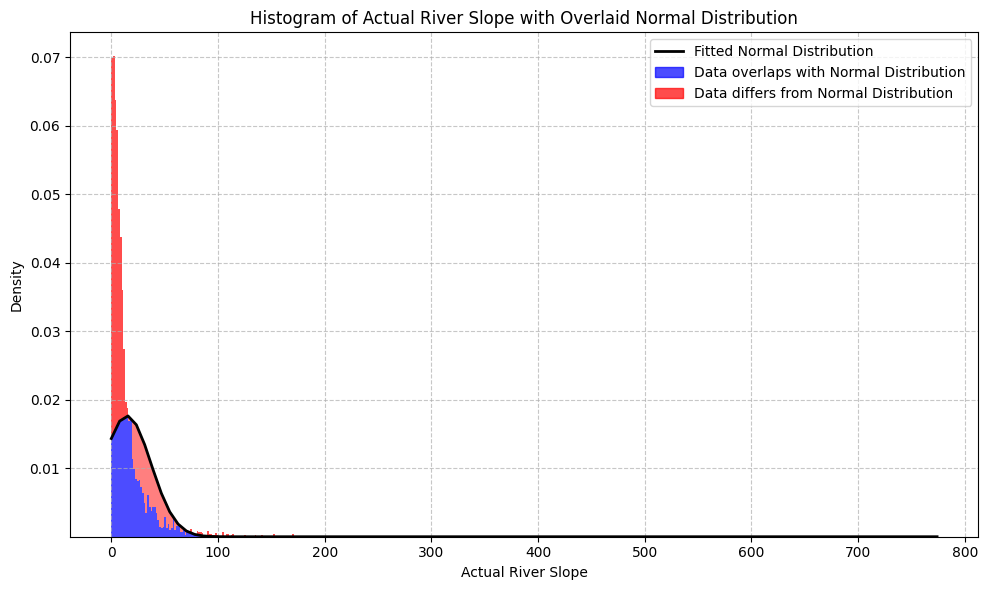

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import seaborn as sns
from matplotlib.patches import Rectangle, Patch

# Prepare the data for Actual_river_slope
river_slope_data = df['Actual_river_slope'].dropna()

# Calculate mean and standard deviation from the sample data
mu_slope, sigma_slope = river_slope_data.mean(), river_slope_data.std()

plt.figure(figsize=(10, 6))
ax = plt.gca() # Get current axes

# Get histogram data (densities and bin edges)
n_slope, bins_slope = np.histogram(river_slope_data, bins='auto', density=True)
bin_centers_slope = (bins_slope[:-1] + bins_slope[1:]) / 2
bar_width_slope = bins_slope[1] - bins_slope[0]

# Calculate PDF values for the fitted normal distribution at bin centers
pdf_at_centers_slope = norm.pdf(bin_centers_slope, mu_slope, sigma_slope)

# Iterate through each bin to plot segments
for i in range(len(bin_centers_slope)):
    center = bin_centers_slope[i]
    hist_h = n_slope[i]
    normal_h = pdf_at_centers_slope[i]

    if hist_h >= normal_h:
        # Histogram bar is above or equal to normal curve
        # Plot blue part up to normal curve
        ax.bar(center, normal_h, width=bar_width_slope, color='blue', alpha=0.7, zorder=1)
        # Plot red part for the excess above normal curve
        if hist_h > normal_h:
            ax.bar(center, hist_h - normal_h, width=bar_width_slope, bottom=normal_h, color='red', alpha=0.7, zorder=1)
    else: # hist_h < normal_h
        # Histogram bar is below normal curve
        # Plot blue part up to hist_h
        ax.bar(center, hist_h, width=bar_width_slope, color='blue', alpha=0.7, zorder=1)
        # Plot red rectangle for the 'gap' (from hist_h to normal_h)
        rect = plt.Rectangle((center - bar_width_slope/2, hist_h), bar_width_slope, normal_h - hist_h,
                             facecolor='red', edgecolor='none', alpha=0.5, zorder=1)
        ax.add_patch(rect)

# Overlay the fitted normal distribution curve
x_plot_slope = np.linspace(river_slope_data.min(), river_slope_data.max(), 100)
pdf_plot_slope = norm.pdf(x_plot_slope, mu_slope, sigma_slope)
line_plot, = ax.plot(x_plot_slope, pdf_plot_slope, color='black', linestyle='-', linewidth=2, label='Fitted Normal Distribution', zorder=2)

# Create custom legend handles for the colored bars
blue_patch = Patch(color='blue', alpha=0.7, label='Data overlaps with Normal Distribution')
red_patch = Patch(color='red', alpha=0.7, label='Data differs from Normal Distribution')

# Combine existing legend handle (for the line) with custom patches
handles = [line_plot, blue_patch, red_patch]
labels = [h.get_label() for h in handles]

ax.set_title('Histogram of Actual River Slope with Overlaid Normal Distribution')
ax.set_xlabel('Actual River Slope')
ax.set_ylabel('Density')
ax.legend(handles=handles, labels=labels)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

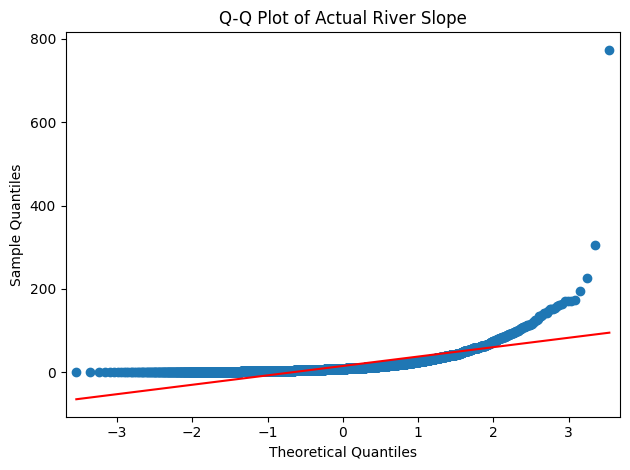

In [31]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.figure(figsize=(8, 6))

# Q-Q plot
sm.qqplot(df['Actual_river_slope'].dropna(), line='s')
plt.title('Q-Q Plot of Actual River Slope')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()

---
## 4. Take 100 samples of 2000 observations of actual_river_slope with replacement, compute the mean for each sample and plot the resulting histogram of means. Test if these 100 mean values are drawn from a normal distribution.

### Conslusion
The histogram and Q–Q plot indicate that the distribution of the 100 sample means of Actual_river_slope is approximately normal, even though the original data is non-normal.

The Shapiro–Wilk test (statistic = 0.989, p = 0.576) supports this, as the p-value is greater than the significance level (α = 0.05), so we fail to reject the null hypothesis of normality.

This result illustrates the Central Limit Theorem, which states that with a large sample size (n = 2000), the distribution of sample means tends toward normality regardless of the original data’s distribution.

In [35]:
# Bootstrap

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

# Ensure the data is clean (no NaNs)
river_slope_cleaned = df['Actual_river_slope'].dropna().values

# Check if there's enough data to sample from
if len(river_slope_cleaned) < 2000:
    print(f"Warning: Not enough data points ({len(river_slope_cleaned)}) to create 2000-observation samples. Adjusting sample size.")
    sample_size = len(river_slope_cleaned) // 2 # Use half of available data as sample size if not enough
    if sample_size == 0:
        sample_size = 1 # Ensure at least one data point
else:
    sample_size = 2000

num_samples = 100
sample_means = []

# 1. Generate 100 bootstrap samples and 2. Compute sample mean for each
for _ in range(num_samples):
    # Sample with replacement
    bootstrap_sample = np.random.choice(river_slope_cleaned, size=sample_size, replace=True)
    sample_means.append(np.mean(bootstrap_sample))

# 3. Store all 100 mean values in an array
sample_means = np.array(sample_means)

print(f"Generated {num_samples} sample means from samples of size {sample_size}.")
print(f"First 5 sample means: {sample_means[:5]}")

Generated 100 sample means from samples of size 2000.
First 5 sample means: [14.358003  14.0799785 14.7837235 14.472794  13.696978 ]


<Figure size 800x600 with 0 Axes>

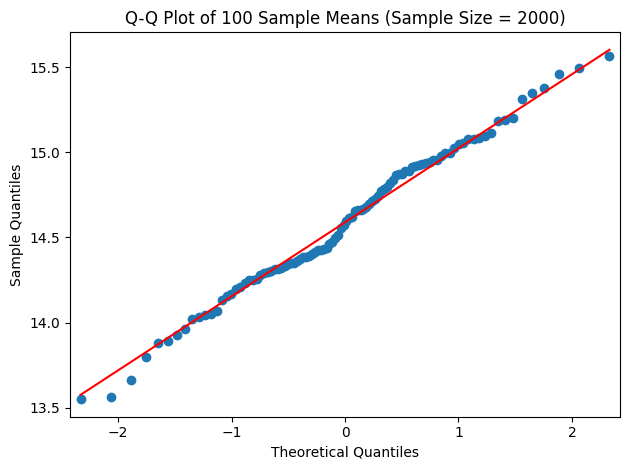


Shapiro-Wilk Test Statistics: 0.989, p=0.576
Significance Level (alpha): 0.05
Interpretation: Sample means look Gaussian (fail to reject H0)


In [34]:
# Assess Normality of Sample Means (Q-Q Plot and Shapiro-Wilk Test)

plt.figure(figsize=(8, 6))
sm.qqplot(sample_means, line='s')
plt.title(f'Q-Q Plot of {num_samples} Sample Means (Sample Size = {sample_size})')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.tight_layout()
plt.show()

# Perform Shapiro-Wilk Test
# H0: The data is normally distributed.
# H1: The data is not normally distributed.

if len(sample_means) > 3: # Shapiro-Wilk test requires at least 3 data points
    stat, p = stats.shapiro(sample_means)
    print('\nShapiro-Wilk Test Statistics: %.3f, p=%.3f' % (stat, p))

    alpha = 0.05
    print(f'Significance Level (alpha): {alpha}')
    if p > alpha:
        print('Interpretation: Sample means look Gaussian (fail to reject H0)')
    else:
        print('Interpretation: Sample means do not look Gaussian (reject H0)')
else:
    print("Not enough sample means to perform Shapiro-Wilk test (need at least 3).")

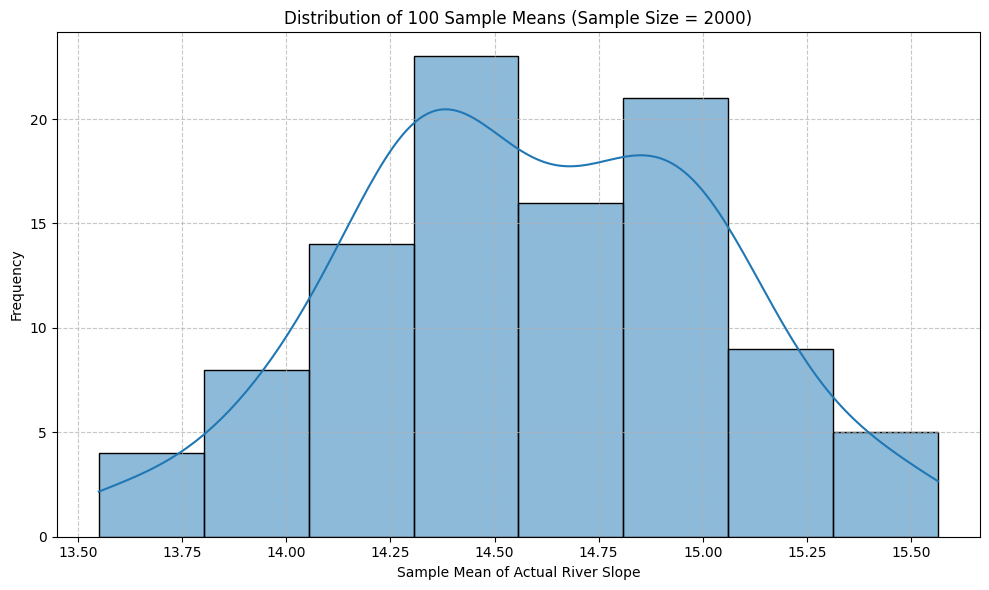

In [33]:
# Histogram of sample means

plt.figure(figsize=(10, 6))
sns.histplot(sample_means, kde=True)
plt.title(f'Distribution of {num_samples} Sample Means (Sample Size = {sample_size})')
plt.xlabel('Sample Mean of Actual River Slope')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

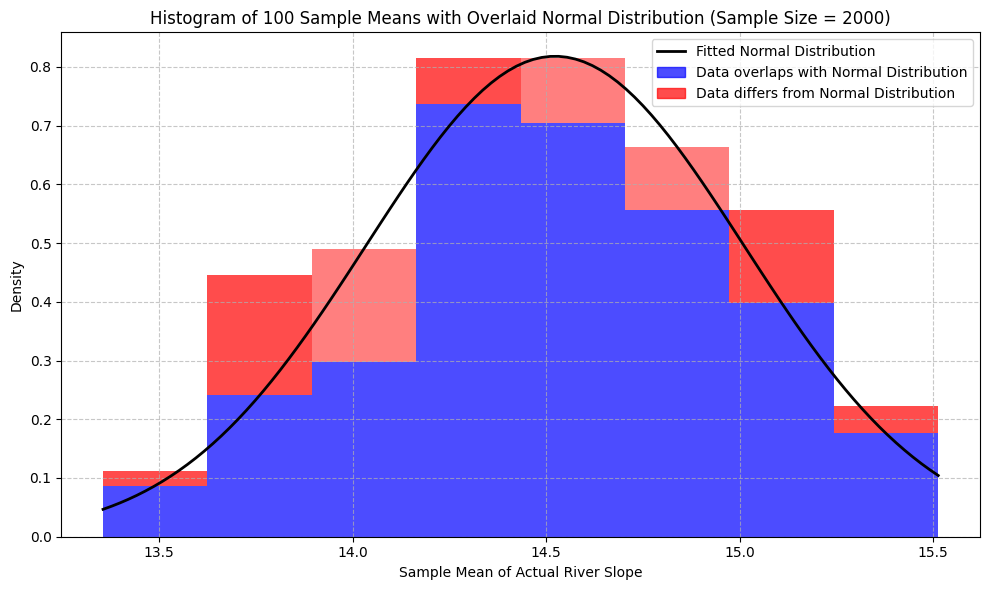

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import seaborn as sns
from matplotlib.patches import Rectangle, Patch

# Calculate mean and standard deviation from the sample means
mu_sample_means, sigma_sample_means = sample_means.mean(), sample_means.std()

plt.figure(figsize=(10, 6))
ax = plt.gca() # Get current axes

# Get histogram data (densities and bin edges) for sample means
n_sample_means, bins_sample_means = np.histogram(sample_means, bins='auto', density=True)
bin_centers_sample_means = (bins_sample_means[:-1] + bins_sample_means[1:]) / 2
bar_width_sample_means = bins_sample_means[1] - bins_sample_means[0]

# Calculate PDF values for the fitted normal distribution at bin centers
pdf_at_centers_sample_means = norm.pdf(bin_centers_sample_means, mu_sample_means, sigma_sample_means)

# Iterate through each bin to plot segments
for i in range(len(bin_centers_sample_means)):
    center = bin_centers_sample_means[i]
    hist_h = n_sample_means[i]
    normal_h = pdf_at_centers_sample_means[i]

    if hist_h >= normal_h:
        # Histogram bar is above or equal to normal curve
        # Plot blue part up to normal curve
        ax.bar(center, normal_h, width=bar_width_sample_means, color='blue', alpha=0.7, zorder=1)
        # Plot red part for the excess above normal curve
        if hist_h > normal_h:
            ax.bar(center, hist_h - normal_h, width=bar_width_sample_means, bottom=normal_h, color='red', alpha=0.7, zorder=1)
    else: # hist_h < normal_h
        # Histogram bar is below normal curve
        # Plot blue part up to hist_h
        ax.bar(center, hist_h, width=bar_width_sample_means, color='blue', alpha=0.7, zorder=1)
        # Plot red rectangle for the 'gap' (from hist_h to normal_h)
        rect = plt.Rectangle((center - bar_width_sample_means/2, hist_h), bar_width_sample_means, normal_h - hist_h,
                             facecolor='red', edgecolor='none', alpha=0.5, zorder=1)
        ax.add_patch(rect)

# Overlay the fitted normal distribution curve
x_plot_sample_means = np.linspace(sample_means.min(), sample_means.max(), 100)
pdf_plot_sample_means = norm.pdf(x_plot_sample_means, mu_sample_means, sigma_sample_means)
line_plot, = ax.plot(x_plot_sample_means, pdf_plot_sample_means, color='black', linestyle='-', linewidth=2, label='Fitted Normal Distribution', zorder=2)

# Create custom legend handles for the colored bars
blue_patch = Patch(color='blue', alpha=0.7, label='Data overlaps with Normal Distribution')
red_patch = Patch(color='red', alpha=0.7, label='Data differs from Normal Distribution')

# Combine existing legend handle (for the line) with custom patches
handles = [line_plot, blue_patch, red_patch]
labels = [h.get_label() for h in handles]

ax.set_title(f'Histogram of {num_samples} Sample Means with Overlaid Normal Distribution (Sample Size = {sample_size})')
ax.set_xlabel('Sample Mean of Actual River Slope')
ax.set_ylabel('Density')
ax.legend(handles=handles, labels=labels)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()